# Level One strategies

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot
import scripts.indicators as ind, scripts.backtester as bct
import scripts.perfomance_metrics as pm

In [3]:
data = pd.read_csv(
    "../data/cleaned_data/MSFT.csv",
    index_col="Date",
    parse_dates=True
)
data.head()

,Open,High,Low,Close,Volume
Date,,,,,
2025-09-02,500.470001,506.000000,496.809998,505.119995,18128000
2025-09-03,503.790009,507.790009,502.320007,505.350006,16345100
2025-09-04,504.299988,508.149994,503.149994,507.970001,15509500
2025-09-05,509.070007,511.970001,492.369995,495.000000,31994800
2025-09-08,498.109985,501.200012,495.029999,498.200012,16771000


In [4]:
data.index

DatetimeIndex(['2025-09-02', '2025-09-03', '2025-09-04', '2025-09-05',
               '2025-09-08', '2025-09-09', '2025-09-10', '2025-09-11',
               '2025-09-12', '2025-09-15',
               ...
               '2026-09-16', '2026-09-17', '2026-09-18', '2026-09-21',
               '2026-09-22', '2026-09-23', '2026-09-24', '2026-09-25',
               '2026-09-28', '2026-09-29'],
              dtype='datetime64[us]', name='Date', length=271, freq=None)

In [5]:
type(data.index)

pandas.DatetimeIndex

In [6]:
sma_20, sma_50, sma_200 = ind.simple_moving_averages(data)

In [7]:
def sma_crossover(data, sma_20, sma_50):

    signal = pd.Series(0, index=data.index)
    signal[sma_20 > sma_50] = 1
    
    return signal

In [8]:
signal = sma_crossover(
    data = data,
    sma_20 = sma_20,
    sma_50 = sma_50
)



In [9]:
results = bct.longs_backtester(data, signal)

In [10]:
results.head(10)

,Open,High,Low,Close,Volume,Position,Market_Return,Strategy_Return,Equity
Date,,,,,,,,,
2025-09-02,500.470001,506.000000,496.809998,505.119995,18128000,0.0,NaN,NaN,NaN
2025-09-03,503.790009,507.790009,502.320007,505.350006,16345100,0.0,0.000455,0.0,1.0
2025-09-04,504.299988,508.149994,503.149994,507.970001,15509500,0.0,0.005185,0.0,1.0
2025-09-05,509.070007,511.970001,492.369995,495.000000,31994800,0.0,-0.025533,-0.0,1.0
2025-09-08,498.109985,501.200012,495.029999,498.200012,16771000,0.0,0.006465,0.0,1.0
2025-09-09,501.429993,502.250000,497.700012,498.410004,14410500,0.0,0.000422,0.0,1.0
2025-09-10,502.980011,503.230011,496.720001,500.369995,21611800,0.0,0.003932,0.0,1.0
2025-09-11,502.250000,503.170013,497.880005,501.010010,18881600,0.0,0.001279,0.0,1.0
2025-09-12,506.649994,512.549988,503.850006,509.899994,23624900,0.0,0.017744,0.0,1.0


In [11]:
metrics = pm.perfomance_metric(results)

In [12]:
metrics

Total Return            -0.131191
CAGR                    -0.122814
Annualized volatility    0.156826
Sharpe                  -0.758600
Max Drawdown            -0.214277
dtype: float64

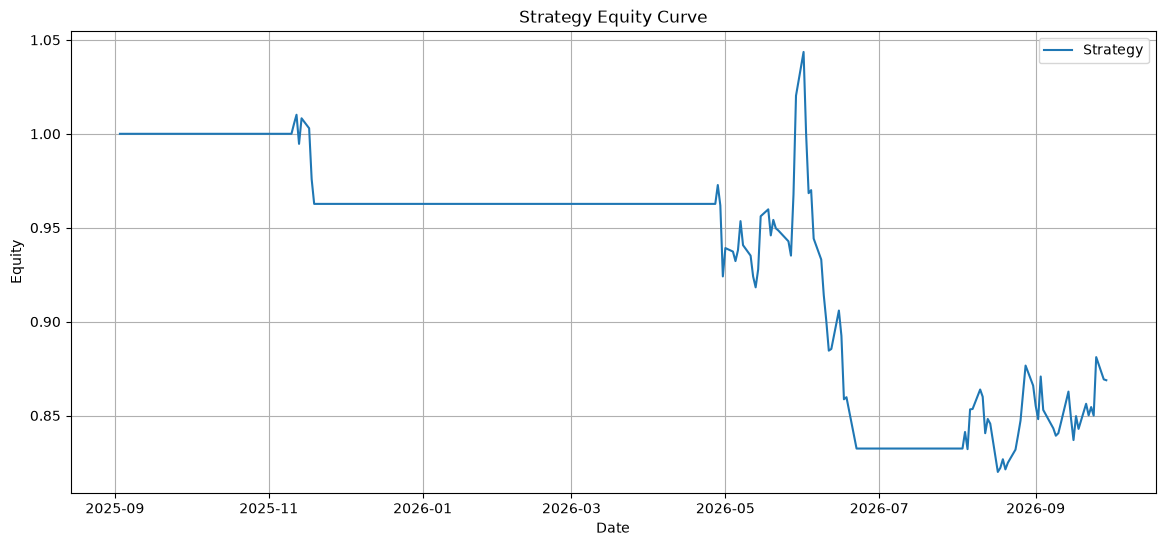

In [13]:
pm.equity_curve(results)